# 08 — Volatility regression

**Question:** can we predict *how much* EUR/USD moves, even though we cannot predict *which way*?

This notebook trains and evaluates the volatility-regression models. To keep a single
source of truth, the actual training lives in `run_full_pipeline.py` (the one script that
reproduces the whole project). This notebook calls that code and shows the results, so the
numbers here are always identical to what the dashboard displays.


## The target: mean |return| over the next 5 days

Tomorrow's |return| alone is a one-observation estimate of volatility. Writing tomorrow's
move as `|r| = sigma * |z|`, most of its variance comes from the random `|z|`, so a model
that knew `sigma` perfectly would still score a low R2 — the ceiling is set by the question.
Averaging |return| over the next 5 trading days lets that noise cancel and leaves the
forecastable volatility `sigma`. That single change moves validation correlation from 0.28
to 0.52 and turns the flat scatter into a forecast that tracks the volatility regime.


In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd
import run_full_pipeline as rfp

# Engineer the 31 features (rebuilds data/processed/fx_features.csv)
f = rfp.build_features()



STAGE 2  engineer the 31 features and the targets
  wrote data\processed\fx_features.csv  4133 rows x 34 cols
  coverage 2010-02-02 -> 2026-07-23


C:\Users\Khang\Desktop\Final Project 2\venv_dl\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Train + evaluate (delegated to the shared pipeline)


In [2]:
reg = rfp.run_regression(f)   # trains 5 models, writes volatility_regression_results.csv



STAGE 3c  volatility regression  (target: mean |return| over the next 5 days)
  rows 4128   train 2889  val 826  test 413
  baseline MAE   mean 0.0972   median 0.0897 (median is the right reference for MAE)


C:\Users\Khang\Desktop\Final Project 2\venv_dl\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Khang\Desktop\Final Project 2\venv_dl\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


               val_mae  val_r2  val_corr  test_mae  test_r2  gain_vs_mean_pct  gain_vs_median_pct
Random Forest   0.0815  0.0912    0.4309    0.0860   0.0090           16.1835              9.1742
XGBoost         0.0904 -0.1365    0.3081    0.0806   0.0351            7.0382             -0.7359
LightGBM        0.0886 -0.1244    0.3586    0.0818   0.0401            8.8991              1.2805
LSTM            0.0751  0.2407    0.5171    0.0789   0.0940           22.7832             16.3257
GRU             0.0772  0.1490    0.4809    0.0779   0.1115           20.5840             13.9426


## Volatility classification — HIGH vs LOW day


In [3]:
ret = f['eurusd'].pct_change()
absmove = ret.abs().shift(-1)
i70, _ = rfp.slices(int(absmove.notna().sum()))
thr = absmove.dropna().iloc[:i70].median()
clf = rfp.run_classification(
    f, (absmove > thr).astype(float).where(absmove.notna()),
    'volatility high/low',
    {'Random Forest': 'vol_clf_random_forest.pkl',
     'XGBoost': 'vol_clf_xgboost.pkl', 'LightGBM': 'vol_clf_lightgbm.pkl',
     'LSTM': 'vol_clf_lstm.pt', 'GRU': 'vol_clf_gru.pt',
     'scaler': 'scaler_volatility.pkl'},
    'volatility_classification_results.csv')


C:\Users\Khang\Desktop\Final Project 2\venv_dl\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Khang\Desktop\Final Project 2\venv_dl\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Khang\Desktop\Final Project 2\venv_dl\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  volatility high/low   majority baseline on val = 55.45%
               train    val   test  val_vs_base
Random Forest  72.99  58.96  57.00         3.51
XGBoost        91.22  58.11  56.52         2.66
LightGBM       89.76  56.42  60.14         0.97
LSTM           61.05  59.56  59.18         4.11
GRU            67.95  59.69  59.66         4.24


## Results

`val_r2 > 0` means the model beats predicting the mean; `gain_vs_median_pct` is the honest
MAE gain (the median is the right baseline for MAE on a skewed target).


In [4]:
pd.read_csv('../models/volatility_regression_results.csv', index_col=0).round(4)


,val_mae,val_r2,val_corr,test_mae,test_r2,gain_vs_mean_pct,gain_vs_median_pct
Random Forest,0.0815,0.0912,0.4309,0.0860,0.0090,16.1835,9.1742
XGBoost,0.0904,-0.1365,0.3081,0.0806,0.0351,7.0382,-0.7359
LightGBM,0.0886,-0.1244,0.3586,0.0818,0.0401,8.8991,1.2805
LSTM,0.0751,0.2407,0.5171,0.0789,0.0940,22.7832,16.3257
GRU,0.0772,0.1490,0.4809,0.0779,0.1115,20.5840,13.9426


In [5]:
# Redraw the predicted-vs-actual figure with the best model (LSTM)
import subprocess
print(subprocess.run([sys.executable, '../make_vol_figure.py'],
                     capture_output=True, text=True).stdout)


wrote figures\models\08_volatility_regression.png  |  R2=+0.2411  corr=0.517  pred_std/actual_std=0.46



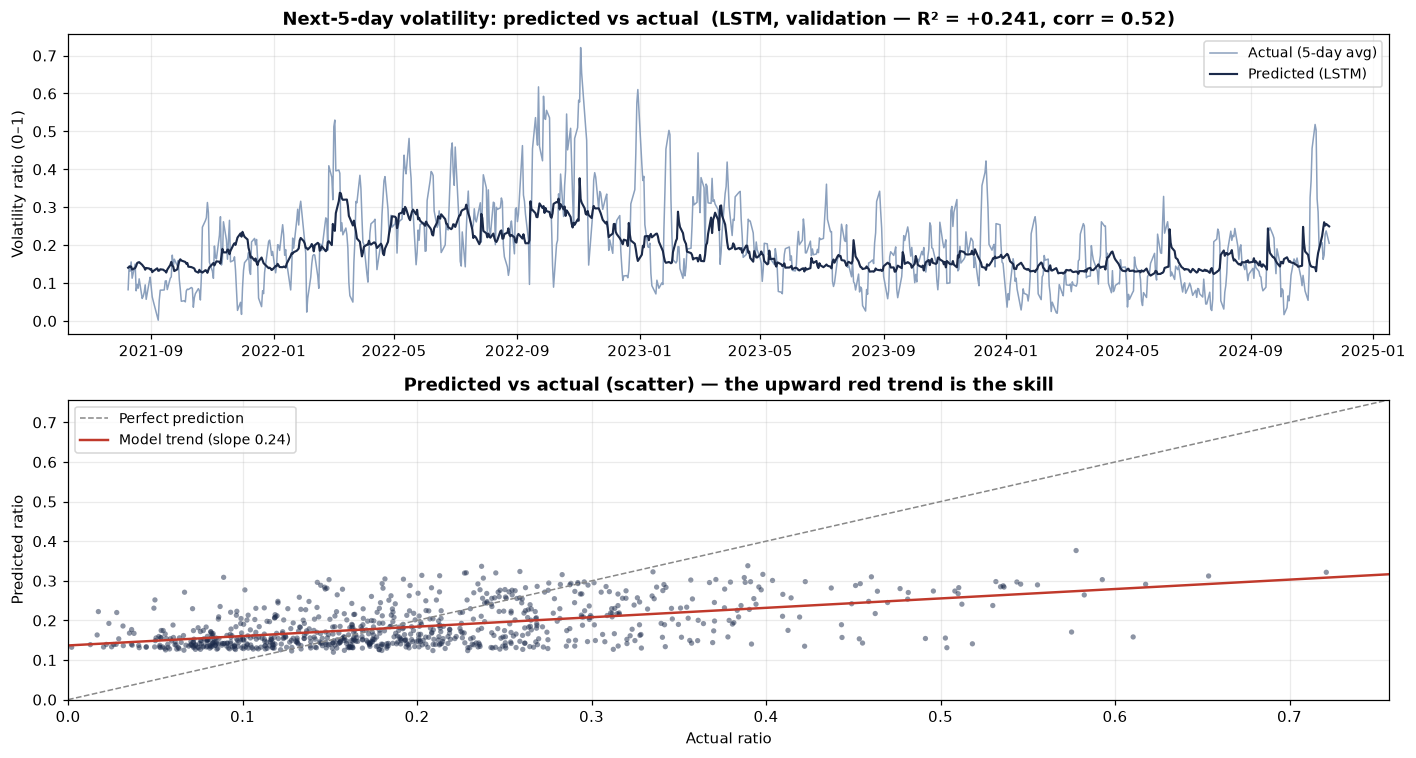

In [6]:
from IPython.display import Image
Image('../figures/models/08_volatility_regression.png')
